In [1]:
%run ./utils.ipynb

### Generate valid valid poses

In [13]:
from geometry_msgs.msg import Point
from robot_benchmark.generators import (
    BoxPoseGenerator,
    RandomPoseGenerator,
    SpherePoseGenerator,
    Generators,
)
from robot_benchmark import (
    IkBenchmark,
    PclPublisher,
)

group_name = 'manipulator'
tool_frame = 'tool0'
base_frame = 'world' 
pose_generator = BoxPoseGenerator(base_frame=base_frame)
start_point = Point(x=0, y=-1, z=0.0)
end_point = Point(x=1, y=1, z=1.5)
step_size = 0.4
poses = pose_generator.generate_poses(
    start_point, end_point, step_size
)
ik_benchmark = IkBenchmark(
    group_name=group_name,
    tool_frame=tool_frame,
)
results = ik_benchmark.run(poses)
successful = [(r[0], r[2]) for r in results if r[1]]
print(len(successful))

22


In [14]:
import itertools
combos = list(itertools.combinations(successful, 2))
print(len(combos))

231


In [15]:
from robot_command.interfaces.moveit_interface import MoveItInterface
from moveit_msgs.msg import RobotState
from actionlib_msgs.msg import GoalStatus

class QuickPlanner:
    MINIMUM_SAMPLING_TIME_S = 0.01
    MIN_SCALING_CORRECTION_FACTOR = 0.005

    def __init__(self):
        self._moveit = MoveItInterface()
        self._moveit.planning_active_changed.append(
            self._on_planning_active_changed
        )
    
    def plan_combo(self, combo):
        self._moveit.set_pilz_industrial_motion_planner_parameters(
            trim_on_failure=False,
            strict_limits=False,
            min_scaling_correction_factor=self.MIN_SCALING_CORRECTION_FACTOR,
            sampling_time_s=self.MINIMUM_SAMPLING_TIME_S,
            output_tcp_joints=False,
        )
        start_state = RobotState()
        return self._moveit.plan(target=combo[1][0].pose, wait=True, start_state=combo[0][1], **self._moveit.LIN_MOVE_PLANNER)
    
    def _on_planning_active_changed(self, active):
        if active:
            return
        success, plan, planning_time, error_details = self._moveit.planning_result
        if self._moveit.planning_status == GoalStatus.SUCCEEDED:
            pass

planner = QuickPlanner()
tcp_vels = []
tcp_accels = []
for combo in combos:
    success, plan, planning_time, error_code = planner.plan_combo(combo)
    if success:
        times, tcp_lin, tcp_vel, tcp_accel = calc_tcp_distance(plan)
        tcp_vels.append(max(abs(v) for v in tcp_vel))
        tcp_accels.append(max(abs(a) for a in tcp_accel))
#print(combos[1][0])

[INFO] [1656945668.634774] [/analyzer_node_107395_1656944775593] [rosout]: error: Failed to generate valid joint trajectory from the Cartesian path
-31
[INFO] [1656945669.154142] [/analyzer_node_107395_1656944775593] [rosout]: error: Failed to generate valid joint trajectory from the Cartesian path
-31
[INFO] [1656945669.934536] [/analyzer_node_107395_1656944775593] [rosout]: error: Failed to generate valid joint trajectory from the Cartesian path
-31
[INFO] [1656945670.453949] [/analyzer_node_107395_1656944775593] [rosout]: error: Failed to generate valid joint trajectory from the Cartesian path
-31
[INFO] [1656945670.480572] [/analyzer_node_107395_1656944775593] [rosout]: error: Failed to generate valid joint trajectory from the Cartesian path
-1
[INFO] [1656945670.673209] [/analyzer_node_107395_1656944775593] [rosout]: error: Failed to generate valid joint trajectory from the Cartesian path
-1
[INFO] [1656945670.698767] [/analyzer_node_107395_1656944775593] [rosout]: error: Failed t

70
1.5173680555285882
4.12385390416304
0.9606999800679364
2.0867542349322226


(array([ 1.,  9., 14., 11.,  4.,  8.,  7.,  8.,  5.,  3.]),
 array([0.31793223, 0.6985244 , 1.07911657, 1.45970873, 1.8403009 ,
        2.22089307, 2.60148524, 2.9820774 , 3.36266957, 3.74326174,
        4.1238539 ]),
 <a list of 10 Patch objects>)

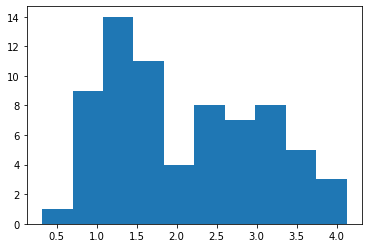

In [32]:
import matplotlib.pyplot as plt

from statistics import mean
print(len(tcp_vels))
print(max(tcp_vels))
print(max(tcp_accels))
print(mean(tcp_vels))
print(mean(tcp_accels))
#plt.hist(tcp_vel, bins=20)
plt.hist(tcp_accels, bins=10)